# Orders Forecast

This notebook builds a basic monthly orders forecasting pipeline.

## Objectives
- Load monthly orders data
- Split into train/test
- Build a Moving Average baseline
- Build a SARIMA model
- Evaluate performance using MAPE
- Visualize actual vs predicted orders

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 1. Data Loading & Preparation

Load monthly orders data and ensure proper datetime formatting.

In [5]:
df = pd.read_csv("orders_monthly.csv")

df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month").reset_index(drop=True)

df.head()

,month,orders
0,2010-12-01,1400
1,2011-01-01,987
2,2011-02-01,998
3,2011-03-01,1321
4,2011-04-01,1149


## 2. Exploratory Data Analysis

Inspect data structure, check for missing values,
and understand basic statistics.

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   month   13 non-null     datetime64[ns]
 1   orders  13 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 340.0 bytes


,month,orders
count,13,13.000000
mean,2011-06-01 07:23:04.615384576,1425.846154
min,2010-12-01 00:00:00,778.000000
25%,2011-03-01 00:00:00,1149.000000
50%,2011-06-01 00:00:00,1331.000000
75%,2011-09-01 00:00:00,1555.000000
max,2011-12-01 00:00:00,2658.000000
std,NaN,484.058510


In [12]:
df.isna().sum()

month     0
orders    0
dtype: int64

### Key Observations

- The dataset contains 13 monthly observations.
- No missing values are present.
- Orders show variability over time, suggesting potential trend or seasonality.

## 3. Time Series Visualization

Visualize monthly order trends to identify patterns,
trend, and potential seasonality.

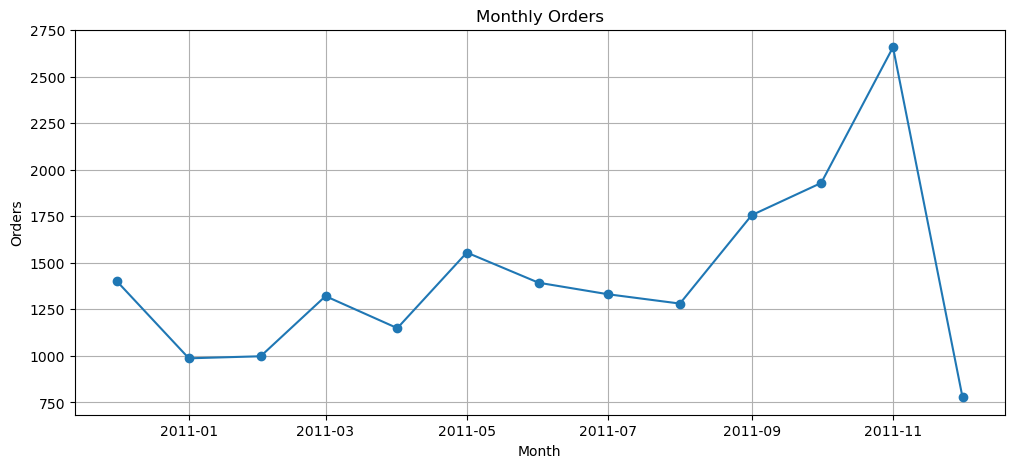

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["orders"], marker="o")
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid(True)
plt.show()

### Insight

Orders show fluctuations over time with a potential upward trend toward later months,
suggesting possible growth or seasonality.

## 4. Train/Test Split

Split the dataset into training and testing sets.

- Training set: historical data
- Test set: last 6 months for evaluation

In [13]:
h = 6   # forecast horizon

train = df.iloc[:-h].copy()
test = df.iloc[-h:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.tail(), test.head()

Train shape: (7, 2)
Test shape: (6, 2)


(       month  orders
 2 2011-02-01     998
 3 2011-03-01    1321
 4 2011-04-01    1149
 5 2011-05-01    1555
 6 2011-06-01    1393,
         month  orders
 7  2011-07-01    1331
 8  2011-08-01    1281
 9  2011-09-01    1756
 10 2011-10-01    1929
 11 2011-11-01    2658)

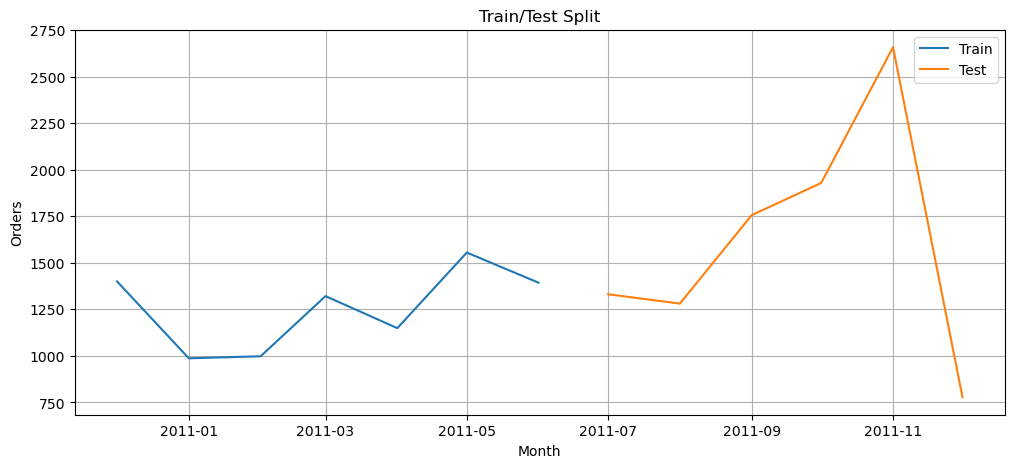

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(train["month"], train["orders"], label="Train")
plt.plot(test["month"], test["orders"], label="Test")
plt.title("Train/Test Split")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(True)
plt.show()

### Insight

The last 6 months are reserved for testing to simulate real-world forecasting scenarios,
where future data is unknown.

## 5. Baseline Model: Moving Average

Use recent historical averages to predict future values.

This serves as a simple and interpretable baseline.

In [15]:
window = 3

last_ma = train["orders"].tail(window).mean()
test["pred_ma"] = last_ma

test[["month", "orders", "pred_ma"]]

,month,orders,pred_ma
7,2011-07-01,1331,1365.666667
8,2011-08-01,1281,1365.666667
9,2011-09-01,1756,1365.666667
10,2011-10-01,1929,1365.666667
11,2011-11-01,2658,1365.666667
12,2011-12-01,778,1365.666667


### Insight

The Moving Average model provides a stable but simplistic forecast,
failing to capture sudden increases or volatility in demand.

## 6. Baseline Evaluation (MAPE)

Evaluate the Moving Average model using Mean Absolute Percentage Error (MAPE).

In [16]:
mape_ma = mean_absolute_percentage_error(test["orders"], test["pred_ma"])
print(f"Moving Average MAPE: {mape_ma:.4f}")
print(f"Moving Average MAPE (%): {mape_ma * 100:.2f}%")

Moving Average MAPE: 0.3080
Moving Average MAPE (%): 30.80%


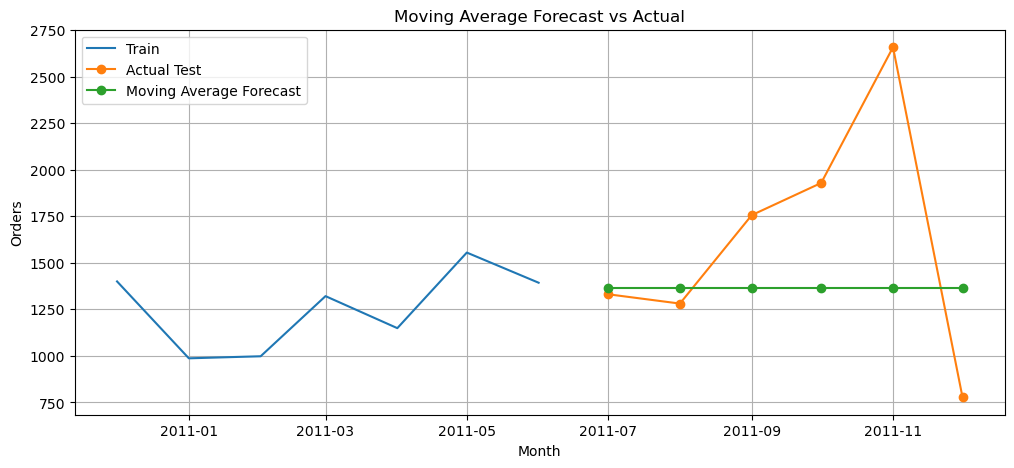

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(train["month"], train["orders"], label="Train")
plt.plot(test["month"], test["orders"], marker="o", label="Actual Test")
plt.plot(test["month"], test["pred_ma"], marker="o", label="Moving Average Forecast")
plt.title("Moving Average Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(True)
plt.show()

## 7. SARIMA Model

Train a SARIMA model to capture trend and seasonality
in the time series data.

In [18]:
y_train = train.set_index("month")["orders"]

model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             orders   No. Observations:                    7
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sat, 21 Mar 2026   AIC                             10.000
Time:                                    17:22:44   BIC                                nan
Sample:                                12-01-2010   HQIC                               nan
                                     - 06-01-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0   

C:\Users\htpar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\htpar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 8. SARIMA Forecast

Generate forecasts for the test period using the trained model.

In [19]:
sarima_forecast = result.forecast(steps=h)

test["pred_sarima"] = sarima_forecast.values
test[["month", "orders", "pred_sarima"]]

,month,orders,pred_sarima
7,2011-07-01,1331,1393.000000
8,2011-08-01,1281,1393.000000
9,2011-09-01,1756,1393.000000
10,2011-10-01,1929,1393.000000
11,2011-11-01,2658,1393.000000
12,2011-12-01,778,2326.333333


## 9. Model Evaluation (SARIMA)

Evaluate SARIMA performance using MAPE and compare with baseline.

In [20]:
mape_sarima = mean_absolute_percentage_error(test["orders"], test["pred_sarima"])
print(f"SARIMA MAPE: {mape_sarima:.4f}")
print(f"SARIMA MAPE (%): {mape_sarima * 100:.2f}%")

SARIMA MAPE: 0.5141
SARIMA MAPE (%): 51.41%


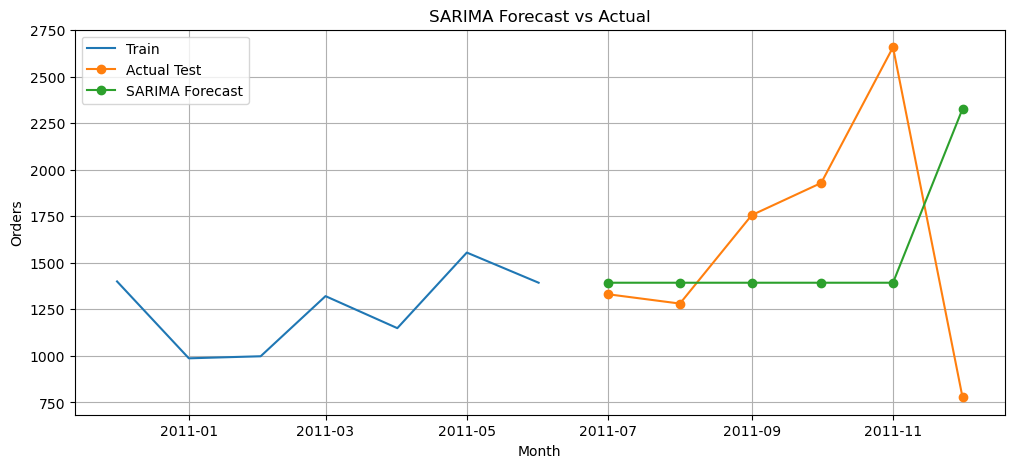

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(train["month"], train["orders"], label="Train")
plt.plot(test["month"], test["orders"], marker="o", label="Actual Test")
plt.plot(test["month"], test["pred_sarima"], marker="o", label="SARIMA Forecast")
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(True)
plt.show()

### Insight

SARIMA attempts to capture temporal dependencies and seasonality,
but its performance is limited due to short data length.

## 10. Forecast Comparison

Compare actual values with:
- Moving Average predictions
- SARIMA predictions

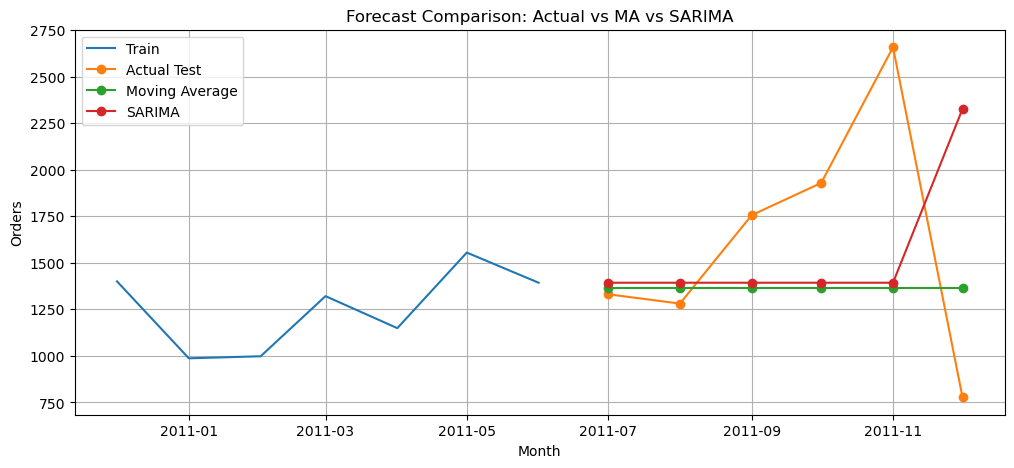

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(train["month"], train["orders"], label="Train")
plt.plot(test["month"], test["orders"], marker="o", label="Actual Test")
plt.plot(test["month"], test["pred_ma"], marker="o", label="Moving Average")
plt.plot(test["month"], test["pred_sarima"], marker="o", label="SARIMA")
plt.title("Forecast Comparison: Actual vs MA vs SARIMA")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(True)
plt.show()

## 11. Model Performance Summary

Summarize model performance using MAPE for comparison.

In [23]:
results = pd.DataFrame({
    "model": ["Moving Average", "SARIMA"],
    "MAPE": [mape_ma, mape_sarima],
    "MAPE_pct": [mape_ma * 100, mape_sarima * 100]
})

results.sort_values("MAPE")

,model,MAPE,MAPE_pct
0,Moving Average,0.308003,30.800332
1,SARIMA,0.514111,51.411077


## 12. Conclusion

- Moving Average provides a simple and stable baseline.
- SARIMA attempts to capture temporal patterns and seasonality.
- Model performance depends on data availability and quality.
- The Moving Average model provides a more stable baseline under limited data conditions,
while SARIMA requires longer time series to be effective.

## Limitations

- Limited historical data (13 observations) restricts model performance
- SARIMA cannot fully capture seasonality with short time series

## Future Improvements

- Extend dataset to 24–36 months
- Incorporate external factors (promotions, holidays)
- Build revenue forecasting (Orders × AOV)
- Apply more advanced models (Prophet, ML models)

## Business Insight

Forecasting monthly orders enables:

- Revenue planning
- Inventory management
- Campaign timing optimization
- Executive KPI forecasting

This bridges descriptive analytics with forward-looking decision-making.

## Executive Summary

This project demonstrates how monthly transactional data
can be transformed into forward-looking business insights
using baseline and time-series forecasting models.

### Recreate Test Window

Recreate the final test window to ensure forecast export uses the correct evaluation period.

## 13. Export Forecast Output

Save the selected forecast results as a CSV file for downstream revenue scenario analysis.

In [9]:
h = 6
train = df.iloc[:-h].copy()
test = df.iloc[-h:].copy()

window = 3
last_ma = train["orders"].tail(window).mean()
test["pred_ma"] = last_ma

forecast_output = test[["month", "pred_ma"]].copy()
forecast_output = forecast_output.rename(columns={"pred_ma": "pred_orders"})
forecast_output["model"] = "Moving Average"

forecast_output.to_csv("orders_forecast.csv", index=False)

forecast_output

,month,pred_orders,model
7,2011-07-01,1365.666667,Moving Average
8,2011-08-01,1365.666667,Moving Average
9,2011-09-01,1365.666667,Moving Average
10,2011-10-01,1365.666667,Moving Average
11,2011-11-01,1365.666667,Moving Average
12,2011-12-01,1365.666667,Moving Average


## Final Model Selection

Moving Average was selected as the final model due to:

- Lower MAPE compared to SARIMA
- Greater stability under limited data
- Better interpretability for business users

This model is used as the baseline for downstream revenue scenario analysis.